In [7]:
import sys
import os
from google.colab import userdata

# 1. 自动从 Colab Secrets 获取你存入的 Token
GIT_TOKEN = userdata.get('GITHUB_TOKEN')

# 2. 根据你的截图填入对应的用户名和仓库名
GIT_USER = "Sheng-Pan"
GIT_REPO = "Decentralized-federated-learning2"

# 3. 构建带认证信息的 URL
repo_url = f"https://{GIT_TOKEN}@github.com/{GIT_USER}/{GIT_REPO}.git"

# 4. 克隆仓库 (如果文件夹已存在则跳过，防止报错)
if not os.path.exists(GIT_REPO):
    !git clone {repo_url}
else:
    print(f"{GIT_REPO} already exists.")

# 5. 将仓库路径添加到系统路径，以便 Python 找到 functions2.py
repo_path = os.path.join("/content", GIT_REPO)
if repo_path not in sys.path:
    sys.path.append(repo_path)


Decentralized-federated-learning2 already exists.


In [ ]:
# 4. 强制更新仓库 (如果存在则拉取最新，不存在则克隆)
if not os.path.exists(GIT_REPO):
    print("Cloning new repository...")
    !git clone {repo_url}
else:
    print(f"{GIT_REPO} already exists. Pulling latest changes...")
    # 切换进目录更新，然后再切换出来
    %cd {GIT_REPO}
    !git pull
    %cd ..

# 5. 关键的一步：强制重新加载已经导入的模块
import importlib
import defense
importlib.reload(defense)

import  theoretical_intensity
importlib.reload(theoretical_intensity)
import MAB_fun
importlib.reload(MAB_fun)
import trainer
importlib.reload(trainer)
import eval_DFL
importlib.reload(eval_DFL)
import main_cnn_GPU
importlib.reload(main_cnn_GPU)

Decentralized-federated-learning already exists. Pulling latest changes...
/content/Decentralized-federated-learning
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
Unpacking objects: 100% (3/3), 1.14 KiB | 1.14 MiB/s, done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
From https://github.com/Sheng-Pan/Decentralized-federated-learning
   ca571d3..7d41ade  main       -> origin/main
Updating ca571d3..7d41ade
Fast-forward
 theoretical_intensity.py | 112 +++++++++++++++++++++++------------------------
 1 file changed, 56 insertions(+), 56 deletions(-)
/content


<module 'main_cnn_GPU' from '/content/Decentralized-federated-learning/main_cnn_GPU.py'>

In [8]:

import os
import time
import pandas as pd
import torch
import gc
from google.colab import drive
import numpy as np
import random
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset, random_split
import random
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification,  get_linear_schedule_with_warmup
import glob
import sys
import time
from datetime import datetime
import pytz
import torch
import torch.nn as nn
import numpy as np
import copy
from torch.utils.data import DataLoader
from collections import defaultdict
import torch.nn.functional as F
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata

from data_loader import allocate_malicious_nodes
from data_loader import generate_topology
from defense import get_high_value_defense_nodes
from main_cnn_GPU import run_simulation_CNN_GPU
from data_loader import set_seed
from data_loader import distribute_data
from data_loader import get_data
from theoretical_intensity import calculate_theoretical_intensity
from data_loader import set_seed


from data_loader import set_seed

# ==========================================
# 1. Hugging Face 配置 (替代 Drive)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
LOCAL_ROOT = "./DFL"
api = HfApi(token=HF_TOKEN)
SAVE_PATH = os.path.join(LOCAL_ROOT, "FL_Experiments/intensity_cnn_final")
os.makedirs(SAVE_PATH, exist_ok=True)
# ==========================================
# 1. CNN 专用辅助函数 (Sensitivity & Trapdoor)
# ==========================================
import sys
import os
NORM_FACTOR = 1
def upload_with_retry(path, repo_path, max_retries=3):
    for i in range(max_retries):
        try:
            api.upload_file(
                path_or_fileobj=path,
                path_in_repo=repo_path,
                repo_id=REPO_ID,
                repo_type="dataset"
            )
            print(f"✅ 上传成功: {os.path.basename(path)}")
            return True
        except Exception as upload_err:
            print(f"⚠️ 第 {i+1} 次上传失败 ({os.path.basename(path)}): {upload_err}")
            if i < max_retries - 1:
                time.sleep(5)  # 等待5秒后重试
            else:
                print(f"❌ 最终上传放弃: {os.path.basename(path)}")
                return False
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
LOCAL_ROOT = "./DFL"
api = HfApi(token=HF_TOKEN) # 👈 必须添加这一行
# 🔥 修正：SAVE_PATH 必须与 snapshot_download 的结构完全对应
# 如果仓库里文件夹叫 Results_transformer_Comparison，这里就不要加 FL_Experiments
SAVE_PATH = os.path.join(LOCAL_ROOT, "FL_Experiments/intensity_cnn_final")
os.makedirs(SAVE_PATH, exist_ok=True)
# ==========================================
#
# ==========================================

#

#
NUM_CLIENTS = 20
BOOST_FACTORS = 2
#
train_ds, test_ds = get_data()
test_loader = DataLoader(test_ds, batch_size=256)

#


NUM_CLIENTS = 20
GLOBAL_ROUNDS = 15
ATK_TYPE = 'neurotoxin'
INTENSITY = 4
normfactor=0.5
seed_val=0
mal_ratio = 0.3
topo_type = 'scale_free'
mech = 'FedAvg'
set_seed(seed_val)

client_datasets = distribute_data(train_ds, NUM_CLIENTS)
G = generate_topology(NUM_CLIENTS, topo_type)
neighbors = {node: list(G.neighbors(node)) for node in G.nodes()}
current_def_budget = 0
num_mal = int(NUM_CLIENTS*mal_ratio)
malicious_clients= list(np.random.choice(range(NUM_CLIENTS), int(NUM_CLIENTS*mal_ratio), replace=False))
defense_nodes = list()
theo_intensities = calculate_theoretical_intensity(
    neighbors, malicious_clients, NUM_CLIENTS, BOOST_FACTORS, lambda_benign=0.3
)
NORMFACTORS = [0.01,0.1,0.5,1,3]
for normfactor in NORMFACTORS:
    csv_filename = f"intensity_CNN_{topo_type}_MR{mal_ratio}_INTENSITY{INTENSITY}_{mech}_seed{seed_val}_normfactor2{normfactor}.csv"
    full_save_path = os.path.join(SAVE_PATH, csv_filename)
    log_filename = f"intensity_CNN_{topo_type}_MR{mal_ratio}_INTENSITY{INTENSITY}_{mech}_seed{seed_val}_normfactor2{normfactor}.txt"
    log_full_path = os.path.join(SAVE_PATH, log_filename)


    start_tick = time.time()

    _, _, accs, asrs = run_simulation_CNN_GPU(
        seed_val, NUM_CLIENTS, defense_nodes, malicious_clients,
        G, neighbors, client_datasets, test_loader,
        atk_type=ATK_TYPE,
        mechanism=mech,
        intensity=INTENSITY,
        norm_factor=normfactor,
        debug_mode=False,
        GLOBAL_ROUNDS=GLOBAL_ROUNDS,
        epochs=5, debug=False
    )
    end_tick = time.time()
    duration_sec = round(end_tick - start_tick, 2)
    #
    result_entry_base = {
        'seed': seed_val,
        'mechanism': mech,
        'malicious_ratio': mal_ratio,
        'topology': topo_type,
        'norm_factor': normfactor,
        'global_rounds': GLOBAL_ROUNDS,
        'duration_sec': duration_sec}
    all_results = []
    for i in range(NUM_CLIENTS):
        client_row = copy.deepcopy(result_entry_base)
        client_row.update({
            'client_id': i,
            'final_acc': accs[i],
            'final_asr': asrs[i],
            'theo_intensity': theo_intensities[i] if i < len(theo_intensities) else 0.0,
            'node_type': 'MAL' if i in malicious_clients else ('DEF' if i in defense_nodes else 'BEN'),
            'neighbors': str(list(neighbors.get(i, [])))
        })
        all_results.append(client_row)
    pd.DataFrame(all_results).to_csv(full_save_path, index=False)

    csv_repo_path = f"FL_Experiments/intensity_cnn_final/{csv_filename}"

    upload_with_retry(full_save_path, csv_repo_path)

print(f"\n🎉 大型实验（含防御比例维度）全部完成！")

🚀 [System] Loading all client datasets directly into VRAM...
📸 [System] Extracting real validation data for S_Z Probe...
✅ Probe successfully extracted, shape: torch.Size([16, 3, 32, 32])

--- Round 1/15 ---
  [Attack Info] Estimated Benign Update Norm: 9.3724

--- Round 2/15 ---
  [Attack Info] Estimated Benign Update Norm: 9.1028

--- Round 3/15 ---
  [Attack Info] Estimated Benign Update Norm: 7.8505

--- Round 4/15 ---
  [Attack Info] Estimated Benign Update Norm: 6.8534

--- Round 5/15 ---
  [Attack Info] Estimated Benign Update Norm: 6.0822

--- Round 6/15 ---
  [Attack Info] Estimated Benign Update Norm: 5.5677

--- Round 7/15 ---
  [Attack Info] Estimated Benign Update Norm: 5.1760

--- Round 8/15 ---
  [Attack Info] Estimated Benign Update Norm: 4.9765

--- Round 9/15 ---
  [Attack Info] Estimated Benign Update Norm: 4.8307

--- Round 10/15 ---
  [Attack Info] Estimated Benign Update Norm: 4.7354

--- Round 11/15 ---
  [Attack Info] Estimated Benign Update Norm: 4.5221

--- Ro

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau  # 导入用于计算 tau 和 p_value 的函数
import os
import glob
import pandas as pd
import numpy as np
from itertools import product
from huggingface_hub import HfApi, snapshot_download
from google.colab import userdata
# ==========================================
# 1. Hugging Face 配置 (替代 Drive 挂载)
# ==========================================
HF_TOKEN = userdata.get('HF_TOKEN') # 请确保 Colab Secret 中有 HF_TOKEN
REPO_ID = "JONESMITH007/DFL"        # 你的仓库 ID
LOCAL_ROOT = "./DFL_CNN_Results"    # 本地缓存路径a

# 注意：根据你之前的上传逻辑，结果存储在仓库的这个子文件夹下
REPO_SUBFOLDER = "FL_Experiments/intensity_cnn_final"
SAVE_DIR = os.path.join(LOCAL_ROOT, REPO_SUBFOLDER)

os.makedirs(SAVE_DIR, exist_ok=True)

# --- 同步远程数据到本地 ---
print("🔄 正在从 Hugging Face 同步数据...")
snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_ROOT,
    allow_patterns=["**/intensity_CNN*.csv"], # 下载所有 CNN 相关的 CSV
    token=HF_TOKEN
)
# ==========================================
# 6. 分析 FedAvg 文件的 final_asr 与 theo_intensity 的相关性 (Kendall Tau)
# ==========================================
print(f"\n{'='*40}")
print("🔍 开始分析 FedAvg 的 final_asr 和 theo_intensity 相关性 (Kendall Tau) - 包含所有节点...")
print(f"{'='*40}")

# 匹配所有包含 FedAvg 的文件
fedavg_pattern = os.path.join(SAVE_DIR, "intensity_CNN*.csv")
fedavg_files = glob.glob(fedavg_pattern)

if not fedavg_files:
    print("\n❌ 未找到任何 FedAvg 相关的 CSV 文件进行相关性分析。")
else:
    print(f"✅ 发现 {len(fedavg_files)} 个 FedAvg 文件，正在提取所有节点数据...\n")

    correlation_results = []
    all_fedavg_nodes = [] # 保存所有文件的数据以供后续汇总绘图

    for f in fedavg_files:
        df = pd.read_csv(f)

        # 1. 保留所有节点（不过滤 MAL 节点）
        df_target = df.copy()

        # 2. 确保目标列为数值类型 (防止字符导致报错)
        df_target['final_asr'] = pd.to_numeric(df_target['final_asr'], errors='coerce')
        df_target['theo_intensity'] = pd.to_numeric(df_target['theo_intensity'], errors='coerce')

        # 3. 去除可能存在的空值
        df_target = df_target.dropna(subset=['final_asr', 'theo_intensity'])

        if len(df_target) > 1: # 至少需要2个点才能算相关性
            # 4. 提取该文件对应的实验参数
            topo = df_target['topology'].iloc[0] if 'topology' in df_target.columns else "Unknown"
            mr = df_target['malicious_ratio'].iloc[0] if 'malicious_ratio' in df_target.columns else "Unknown"
            seed = df_target['seed'].iloc[0] if 'seed' in df_target.columns else "Unknown"

            # 5. 使用 scipy 计算 Kendall Tau 系数和 p 值
            tau, p_value = kendalltau(df_target['final_asr'], df_target['theo_intensity'])

            # 6. 记录结果
            correlation_results.append({
                'File': os.path.basename(f),
                'Topology': topo,
                'Mal_Ratio': mr,
                'Seed': seed,
                'Nodes_Count': len(df_target),
                'Kendall_Tau': tau,
                'P_Value': p_value,
                'Is_Significant': 'Yes' if p_value < 0.05 else 'No'
            })

            all_fedavg_nodes.append(df_target)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ==========================================
# 1. 数据预处理
# ==========================================
# 核心：按理论强度 (theo_intensity) 从小到大排序，直观展示趋势
df = df.sort_values(by='theo_intensity').reset_index(drop=True)

# 创建 X 轴的标签，格式例如： "C0\n(BEN)" 或 "C16\n(MAL)"
df['client_label'] = 'C' + df['client_id'].astype(str) + '\n(' + df['node_type'] + ')'

# 为良性节点和恶意节点分配不同的颜色
colors_theo = ['#1F77B4' if nt != 'MAL' else '#002E5D' for nt in df['node_type']]
colors_asr  = ['#FF7F0E' if nt != 'MAL' else '#D62728' for nt in df['node_type']]

# ==========================================
# 2. 绘图准备
# ==========================================
x = np.arange(len(df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 7))

# --- 左轴：理论强度 (柱状图) ---
rects1 = ax1.bar(x - width/2, df['theo_intensity'], width, color=colors_theo, edgecolor='white')
ax1.set_ylabel('Theoretical Intensity (Topology Danger)', color='#1F77B4', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1F77B4', labelsize=12)
ax1.set_xlabel('Client ID & Role', fontsize=14, fontweight='bold')

# 设置 X 轴刻度和标签
ax1.set_xticks(x)
ax1.set_xticklabels(df['client_label'], fontsize=11)

# 🌟 视觉高亮：将 X 轴上所有的 MAL (恶意节点) 文本标红并加粗
for text in ax1.get_xticklabels():
    if 'MAL' in text.get_text():
        text.set_color('#D62728')
        text.set_fontweight('bold')

# 添加左轴网格线 (降低透明度防止干扰)
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)

# --- 右轴：ASR (柱状图) ---
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, df['final_asr'], width, color=colors_asr, edgecolor='white')

# 动态判断 ASR 是 0-1 还是 0-100% 并固定范围
asr_max = df['final_asr'].max()
is_percentage = asr_max > 1.5
ax2.set_ylabel(f'Final ASR {"(%)" if is_percentage else ""}', color='#D62728', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#D62728', labelsize=12)
ax2.set_ylim(0, 105 if is_percentage else 1.05)

# ==========================================
# 3. 图例美化
# ==========================================
legend_elements = [
    Patch(facecolor='#1F77B4', edgecolor='w', label='Theoretical Intensity (BEN)'),
    Patch(facecolor='#002E5D', edgecolor='w', label='Theoretical Intensity (MAL)'),
    Patch(facecolor='#FF7F0E', edgecolor='w', label='Final ASR (BEN)'),
    Patch(facecolor='#D62728', edgecolor='w', label='Final ASR (MAL)')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, shadow=True)

plt.title('Comparison of Topological Vulnerability (Theoretical) vs. Actual ASR per Client',
          fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import snapshot_download
from google.colab import userdata

# ==========================================
# 1. 从 Hugging Face 拉取实验结果
# ==========================================
print("正在从 Hugging Face 获取实验数据...")
HF_TOKEN = userdata.get('HF_TOKEN')
REPO_ID = "JONESMITH007/DFL"
FOLDER_PATH = "FL_Experiments/intensity_cnn_final"

# 下载指定文件夹下的所有 csv 文件到本地缓存
local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    allow_patterns=f"{FOLDER_PATH}/*.csv",
    token=HF_TOKEN
)

# 获取所有下载的 CSV 文件路径
csv_files = glob.glob(os.path.join(local_dir, FOLDER_PATH, "*.csv"))
print(f"成功找到 {len(csv_files)} 个实验记录文件。")

# ==========================================
# 2. 数据整合与处理
# ==========================================
# 读取并合并所有 DataFrame
df_list = [pd.read_csv(f) for f in csv_files]
df_all = pd.concat(df_list, ignore_index=True)

# 🌟 核心：我们主要关注后门在“良性节点(BEN)”中的扩散情况
# 恶意节点(MAL)的 ASR 通常本来就是 100%，会干扰全局相变的观察
df_benign = df_all[df_all['node_type'] == 'BEN']

# 按 norm_factor 分组，计算平均 ASR 和平均 ACC
df_phase = df_benign.groupby('norm_factor')[['final_asr', 'final_acc']].mean().reset_index()
# 确保按 norm_factor 从小到大排序
df_phase = df_phase.sort_values(by='norm_factor').reset_index(drop=True)

print("\n聚合后的相变数据：")
print(df_phase)

# ==========================================
# 3. 绘制相变曲线 (双 Y 轴折线图)
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- X 轴设置 ---
# 因为 norm_factor 的取值跨度较大 (0.01, 0.1, 0.5, 1, 3)，
# 如果点挤在一起，可以取消下面这行的注释，启用对数坐标轴：
# ax1.set_xscale('log')
ax1.set_xlabel('Norm Factor (Defense / Clipping Threshold)', fontsize=14, fontweight='bold')
ax1.set_xticks(df_phase['norm_factor'])
ax1.set_xticklabels(df_phase['norm_factor'], fontsize=12)

# --- 左轴：ASR (红色粗线) ---
color_asr = '#D62728'
ax1.set_ylabel('Average ASR on Benign Nodes (%)', color=color_asr, fontsize=14, fontweight='bold')
line1 = ax1.plot(df_phase['norm_factor'], df_phase['final_asr'],
                 color=color_asr, marker='o', linewidth=3, markersize=8, label='ASR (Attack Success)')
ax1.tick_params(axis='y', labelcolor=color_asr, labelsize=12)
ax1.set_ylim(-5, 105) # 纵坐标固定 0-100%

# 添加网格线
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 右轴：ACC (蓝色虚线) ---
ax2 = ax1.twinx()
color_acc = '#1F77B4'
ax2.set_ylabel('Average ACC on Benign Nodes (%)', color=color_acc, fontsize=14, fontweight='bold')
line2 = ax2.plot(df_phase['norm_factor'], df_phase['final_acc'],
                 color=color_acc, marker='s', linestyle='--', linewidth=3, markersize=8, label='ACC (Main Task)')
ax2.tick_params(axis='y', labelcolor=color_acc, labelsize=12)
ax2.set_ylim(-5, 105)

# --- 图例与标题 ---
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=12, frameon=True, shadow=True)

plt.title('Phase Transition of Backdoor Diffusion vs. Norm Factor', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [5]:
pd.DataFrame(all_results)

[{'seed': 0,
  'mechanism': 'FedAvg',
  'malicious_ratio': 0.3,
  'topology': 'scale_free',
  'norm_factor': 1,
  'scale_factor': 0.8,
  'global_rounds': 5,
  'duration_sec': 172.45,
  'client_id': 0,
  'final_acc': 57.99683332443237,
  'final_asr': 69.11110877990723,
  'theo_intensity': np.float64(0.3616995682132246),
  'node_type': 'BEN',
  'neighbors': '[1, 2, 3, 4, 5, 6, 7, 8, 11, 15]'},
 {'seed': 0,
  'mechanism': 'FedAvg',
  'malicious_ratio': 0.3,
  'topology': 'scale_free',
  'norm_factor': 1,
  'scale_factor': 0.8,
  'global_rounds': 5,
  'duration_sec': 172.45,
  'client_id': 1,
  'final_acc': 72.3357081413269,
  'final_asr': 97.33333587646484,
  'theo_intensity': np.float64(1.7045960523614414),
  'node_type': 'MAL',
  'neighbors': '[0, 3, 4, 5, 9]'},
 {'seed': 0,
  'mechanism': 'FedAvg',
  'malicious_ratio': 0.3,
  'topology': 'scale_free',
  'norm_factor': 1,
  'scale_factor': 0.8,
  'global_rounds': 5,
  'duration_sec': 172.45,
  'client_id': 2,
  'final_acc': 66.270786523

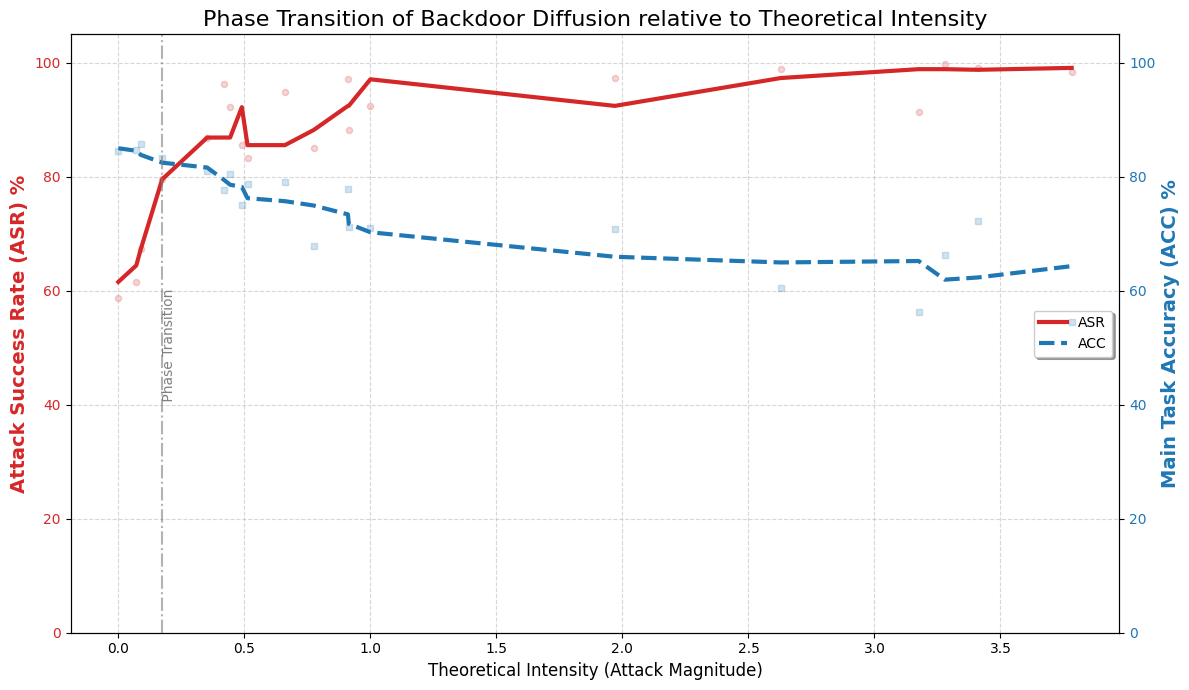

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
try:
    df = pd.DataFrame(all_results)

    x_col = 'theo_intensity'
    y1_col = 'final_asr'
    y2_col = 'final_acc'
    df = df.sort_values(by=x_col).reset_index(drop=True)

    window_size = 5

    df['ASR_Smooth'] = df[y1_col].rolling(window=window_size, center=True, min_periods=1).median()


    df['ACC_Smooth'] = df[y2_col].rolling(window=window_size, center=True, min_periods=1).mean()

    # ==========================================
    # 4. 绘图
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(12, 7))


    color1 = '#D62728'
    ax1.set_xlabel('Theoretical Intensity (Attack Magnitude)', fontsize=12)
    ax1.set_ylabel('Attack Success Rate (ASR) %', color=color1, fontsize=14, fontweight='bold')


    ax1.scatter(df[x_col], df[y1_col], color=color1, alpha=0.2, s=20, label='Raw ASR (Noise)')


    ax1.plot(df[x_col], df['ASR_Smooth'], color=color1, linewidth=3, label='ASR')

    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, 105)
    ax1.grid(True, which='major', linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    color2 = '#1F77B4'
    ax2.set_ylabel('Main Task Accuracy (ACC) %', color=color2, fontsize=14, fontweight='bold')

    ax2.scatter(df[x_col], df[y2_col], color=color2, alpha=0.2, s=20, marker='s')

    ax2.plot(df[x_col], df['ACC_Smooth'], color=color2, linewidth=3, linestyle='--', label='ACC')

    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 105)

    gradient = np.gradient(df['ASR_Smooth'])
    max_gradient_idx = np.argmax(gradient)
    transition_x = df[x_col].iloc[max_gradient_idx]

    plt.axvline(x=transition_x, color='gray', linestyle='-.', alpha=0.6)
    plt.text(transition_x, 50, ' Phase Transition', rotation=90, color='gray', va='center')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend([lines1[1], lines2[0]], [labels1[1], labels2[0]], loc='center right', frameon=True, shadow=True)

    plt.title('Phase Transition of Backdoor Diffusion relative to Theoretical Intensity', fontsize=16)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"发生错误: {e}")